#### 1. Set up the reaction graph from DFT data 

In [ ]:
from arcs.generate import GraphGenerator

graph = GraphGenerator().from_file(
    filename='../src/arcs/data/dft_data.json',
    temperature=248,
    pressure=20,
    max_reaction_length=5,
    log_K = False
)

#### 2. Sample the `graph`

In [ ]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':30,'O2':10,'SO2':10,'H2S':0,'NO2':10}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=4,nsamples=1000)

  0%|          | 0/100 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [10]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

2 H2 + 1 O2 = 2 H2O                       54
1 H2O + 2 NO2 = 1 HNO3 + 1 HNO2           18
1 H2 + 1 NO2 = 1 H2O + 1 NO               16
1 S8 + 8 NO2 = 8 SO2 + 4 N2               12
1 O2 + 2 NO = 2 NO2                       11
1 H2O + 3 NO2 = 2 HNO3 + 1 NO             11
1 H2O + 1 SO2 + 1 NO2 = 1 H2SO4 + 1 NO    11
1 H2O + 1 NO2 + 1 NO = 2 HNO2              8
8 O2 + 1 S8 = 8 SO2                        8
1 H2 + 1 O2 + 1 SO2 = 1 H2SO4              8
3 H2 + 1 SO2 = 2 H2O + 1 H2S               8
1 H2 + 1 H2SO4 = 2 H2O + 1 SO2             7
4 H2O + 1 S8 + 4 HNO3 = 8 SO2 + 4 NH3      4
2 H2 + 2 SO2 = 1 H2SO4 + 1 H2S             4
1 H2 + 1 HNO3 = 1 H2O + 1 HNO2             4
2 H2 + 6 NO2 = 4 HNO3 + 1 N2               4
3 O2 + 2 NH3 = 2 H2O + 2 HNO2              4
1 H2 + 1 SO2 + 1 NO2 = 1 H2SO3 + 1 NO      4
1 H2 + 2 O2 + 2 NO = 2 HNO3                4
1 O2 + 2 H2O + 4 NO2 = 4 HNO3              3
dtype: int64

#### 4. generate mean concentrations and differences

In [11]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
print(average_data.round(2).to_string())

       initial   mean  diff   sem   std    var
NO2       10.0   6.01 -3.99  0.32  4.65  21.62
H2O       30.0  26.73 -3.27  0.29  4.24  18.02
SO2       10.0   8.65 -1.35  0.21  3.02   9.11
NH3        0.0   0.00  0.00  0.00  0.00   0.00
S8         0.0   0.00  0.00  0.00  0.00   0.00
H2SO3      0.0   0.02  0.02  0.01  0.12   0.01
H2S        0.0   0.07  0.07  0.02  0.32   0.10
O2        10.0  10.08  0.08  0.03  0.47   0.22
N2         0.0   0.09  0.09  0.02  0.35   0.12
H2         0.0   0.50  0.50  0.08  1.15   1.32
HNO2       0.0   0.78  0.78  0.12  1.78   3.18
NO         0.0   0.98  0.98  0.16  2.32   5.40
H2SO4      0.0   1.25  1.25  0.20  2.86   8.21
HNO3       0.0   2.06  2.06  0.20  2.92   8.52


#### 5. Plot 

/var/folders/40/xmstzxyn7377k__pn0yxn6w80000gn/T/ipykernel_95482/949321809.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(name='RdBu')  # or any other colormap


<Axes: >

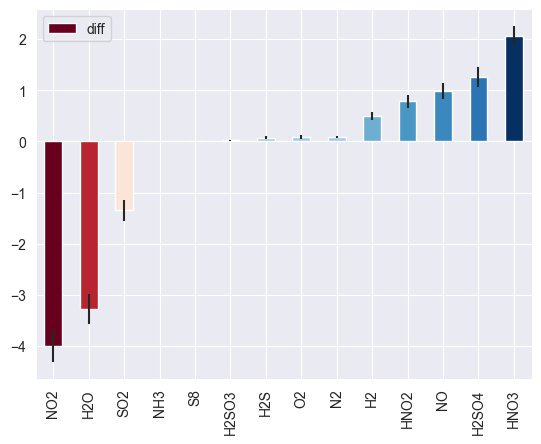

In [12]:
import seaborn as sns 
from matplotlib.cm import get_cmap
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors)

#### 5. generate a `pyvis` graph 

In [18]:
pyvis_kwargs = {'width':'50%','notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

In [121]:
! open example_pyvis_graph.html